# 2.EDA and Visualization of Netflix Dataset

In [32]:
# importing Liabraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

plt.style.use("ggplot")
print("Liabraries imported sucessfully!")

Liabraries imported sucessfully!


In [33]:
# Loading cleaned dataset

df = pd.read_csv("../data/cleaned/cleaned_netflix.csv")
print("Data file loaded!")

Data file loaded!


# Dataset Overview

This section provides a quick understanding of the cleaned Netflix dataset.

In [34]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_age,decade,month_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Listed,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,2020,9,2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,2020,9,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,2020,9,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Listed,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,2020,9,2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,2020,9,2021


In [35]:
df.shape

(8807, 16)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
 12  content_age   8807 non-null   int64
 13  decade        8807 non-null   int64
 14  month_added   8807 non-null   int64
 15  year_added    8807 non-null   int64
dtypes: int64(5), str(11)
memory usage: 1.1 MB


In [37]:
df.describe()

,release_year,content_age,decade,month_added,year_added
count,8807.000000,8807.000000,8807.000000,8807.000000,8807.000000
mean,2014.180198,11.819802,2009.108664,6.654479,2018.871352
std,8.819312,8.819312,9.228119,3.437010,1.574166
min,1925.000000,5.000000,1920.000000,1.000000,2008.000000
25%,2013.000000,7.000000,2010.000000,4.000000,2018.000000
50%,2017.000000,9.000000,2010.000000,7.000000,2019.000000
75%,2019.000000,13.000000,2010.000000,10.000000,2020.000000
max,2021.000000,101.000000,2020.000000,12.000000,2021.000000


# EDA Analysis

Question 1: which type dominates netflix?

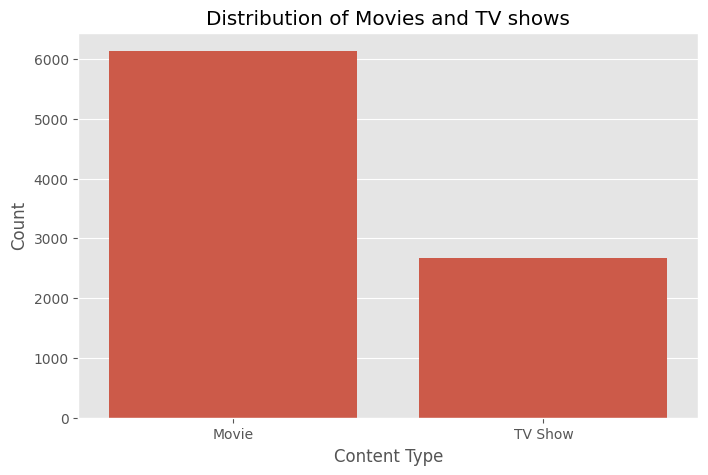

In [50]:
plt.figure(figsize = (8,5))
sbn.countplot(x = "type", data = df)

plt.title("Distribution of Movies and TV shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.savefig("../visuals/Distribution_content.png")

plt.show()

### Insight

Movies dominate the Netflix platform compared to TV Shows, indicating a stronger focus on movie-based content acquisition.

Question 2: How has Netflix content grown over time?

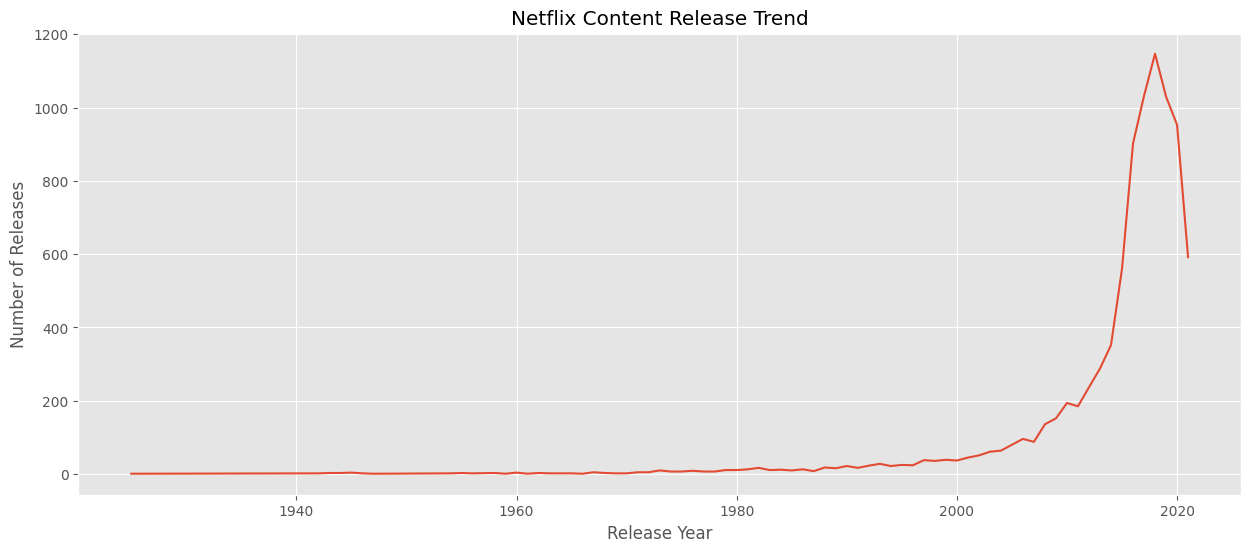

In [51]:
release_trend = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(15,6))

release_trend.plot()

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")

plt.savefig("../visuals/content_release.png")

plt.show()

### Insight

Netflix content releases increased rapidly after 2015, showing aggressive platform expansion and content acquisition strategy.

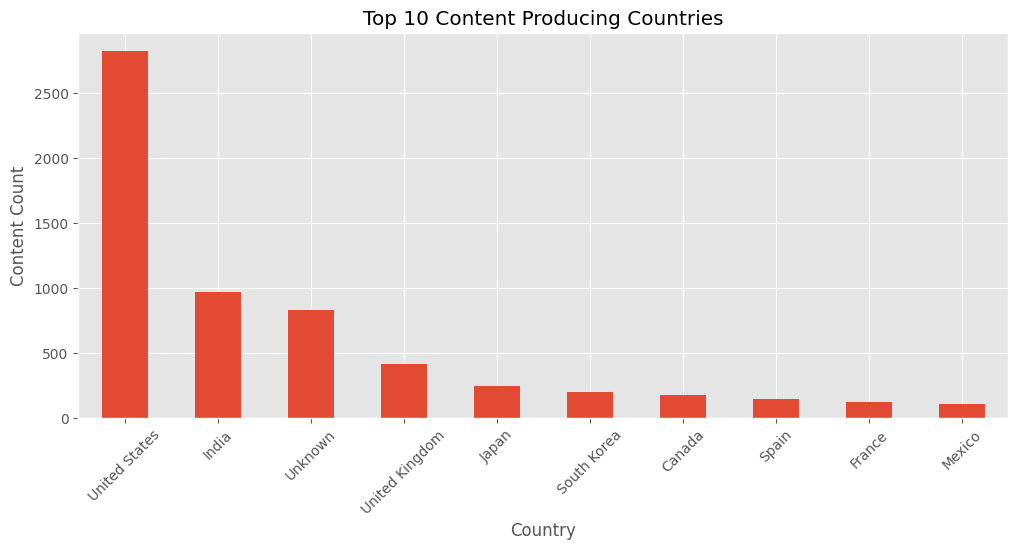

In [52]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(12,5))
top_countries.plot(kind="bar")

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Content Count")

plt.xticks(rotation=45)

plt.savefig("../visuals/Top 10 Country.png")

plt.show()

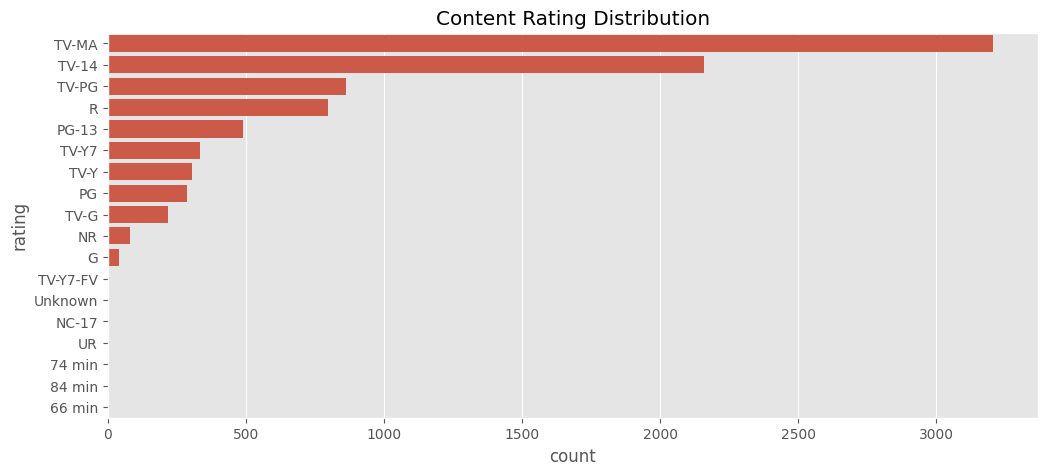

In [53]:
plt.figure(figsize=(12,5))

sbn.countplot(y="rating",
              data=df,
              order=df["rating"].value_counts().index)
plt.title("Content Rating Distribution")

plt.savefig("../visuals/content_rating.png")

plt.show()

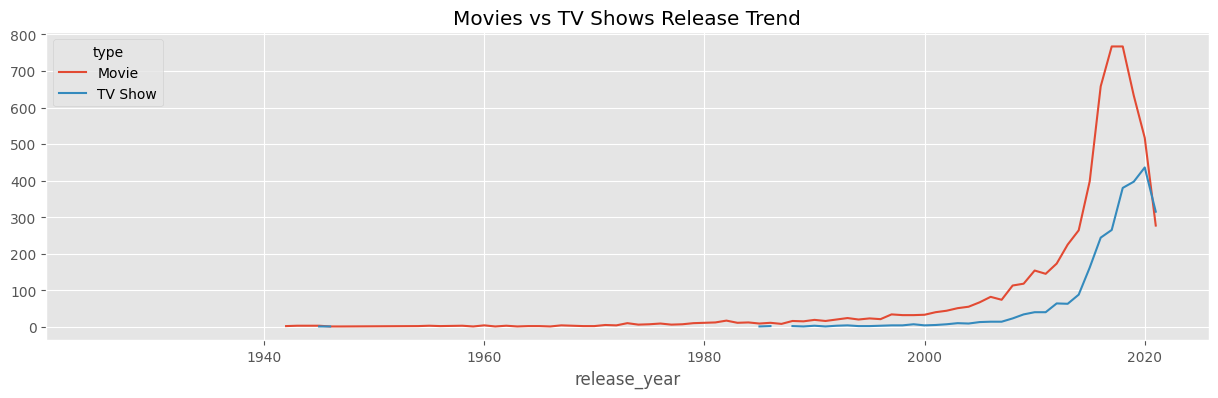

In [54]:
content_year = df.groupby(["release_year","type"]).size().unstack()

content_year.plot(figsize=(15,4))
plt.title("Movies vs TV Shows Release Trend")

plt.savefig("../visuals/release_trends.png")

plt.show()

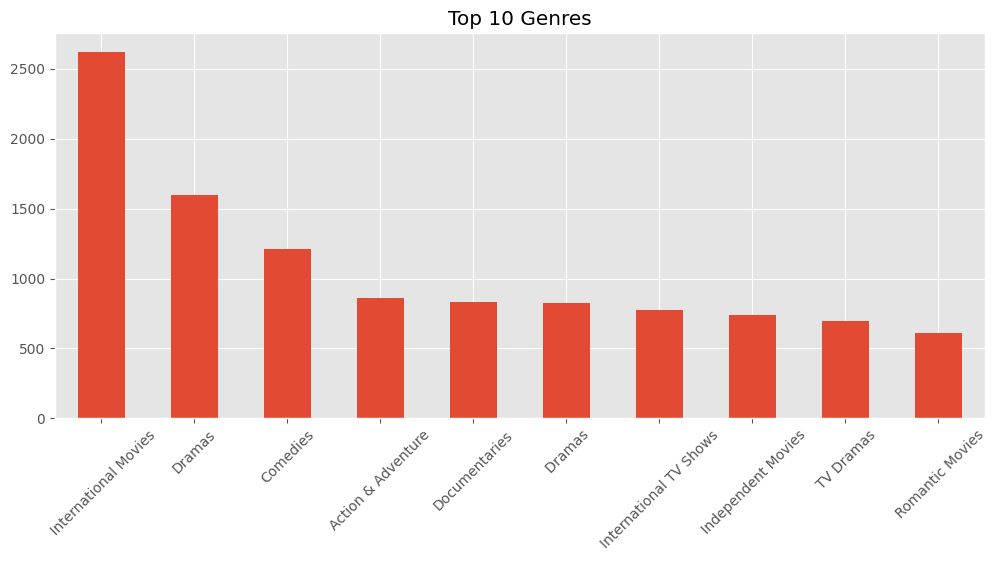

In [55]:
genres = df["listed_in"].str.split(",", expand=True).stack()

top_genres = genres.value_counts().head(10)
plt.figure(figsize=(12,5))
top_genres.plot(kind="bar")
plt.title("Top 10 Genres")
plt.xticks(rotation=45)

plt.savefig("../visuals/Top 10 Genres.png")

plt.show()

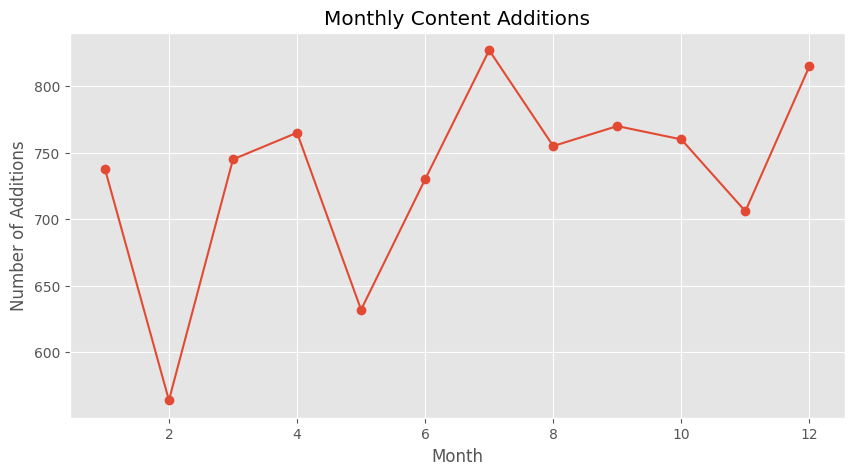

In [56]:
monthly_content = df["month_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))
monthly_content.plot(kind="line", marker="o")
plt.title("Monthly Content Additions")
plt.xlabel("Month")
plt.ylabel("Number of Additions")

plt.savefig("../visuals/Monthly_content.png")

plt.show()

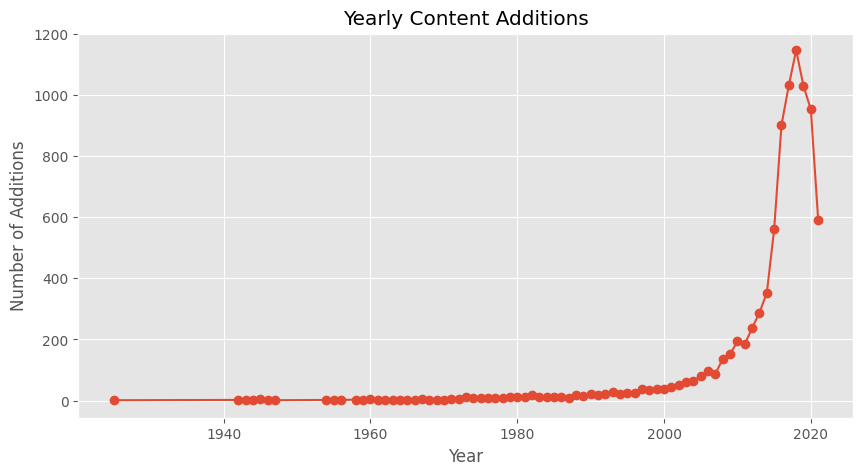

In [57]:
yearly_content = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_content.plot(kind="line", marker="o")
plt.title("Yearly Content Additions")
plt.xlabel("Year")
plt.ylabel("Number of Additions")

plt.savefig("../visuals/Yealry_content.png")

plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ritu.panchal\AppData\Local\Temp\ipykernel_22628\2214098708.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies["duration_int"] = movies["duration"].str.extract("(\d+)").astype(float)


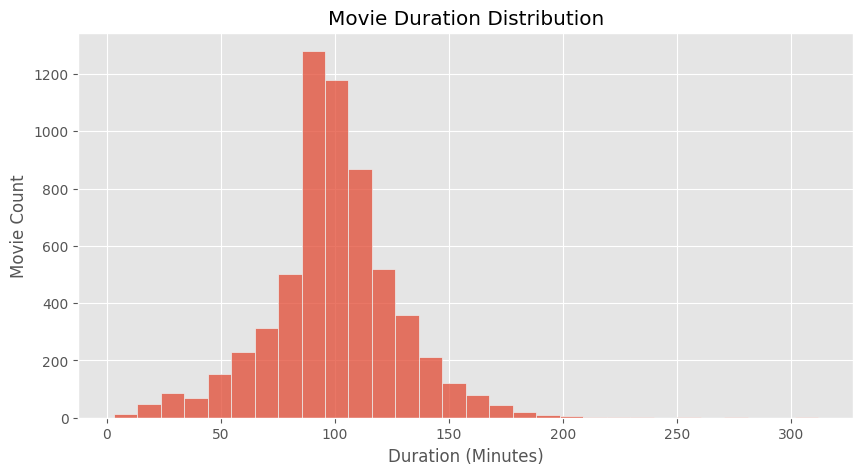

In [58]:
movies = df[df["type"] == "Movie"]

movies["duration_int"] = movies["duration"].str.extract("(\d+)").astype(float)

plt.figure(figsize=(10,5))
sbn.histplot(movies["duration_int"], bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Movie Count")

plt.savefig("../visuals/Movie_Durations.png")

plt.show()


# Final Conclusion

Key findings from exploratory data analysis:

- Movies dominate Netflix content
- Content growth accelerated significantly after 2015
- The United States is the leading content producer
- Drama and International Movies are highly dominant genres
- TV-MA is the most common content rating